In [1]:
from rsl_rl.env import VecEnv
from rsl_rl.runners import OnPolicyRunner
import torch
import numpy as np
torch.set_printoptions(precision=5, linewidth=200, sci_mode=False)

N          = 6924300
state_dim  = 8
action_dim = 5
T          = 241
budget     = 3600.
N_envs     = 1
ΔT         = 1
device     = 'cpu'
usr_std = 0.1
seed = 0

parameter_static = dict(N          = N,
                        B          = budget,
                        T          = T,
                        alpha      = 0.6,
                        v_max      = 0.2/14,
                        cost_ti    = 0.0977,
                        cost_ta    = 0.02,
                        cost_v     = 0.07,
                        cost_poc_0 = 0.000369,
                        cost_poc_1 = 0.001057,
                        pid        = 1.10/1000,
                        psr        = 0.7,
                        pid_plus   = 0.1221/1000,
                        pir        = 1/8,
                        prs        = 1/7)

Random_mean = {"beta2" : 0.5,
               "beta1" : 0.5,
               "pei"   : 0.5,
               "per"   : 0.5}
usr_std = 0.5
space = {"beta2" : [Random_mean['beta2'], Random_mean['beta2'] * usr_std],
         "beta1" : [Random_mean['beta1'], Random_mean['beta1'] * usr_std],
         "pei"   : [Random_mean['pei'], Random_mean['pei'] * usr_std],
         "per"   : [Random_mean['per'], Random_mean['per'] * usr_std]}

Init_state = torch.tensor([[1 - 528 / N, 528 / N, 0, 0, 0, 0, 0, 0]], 
                         dtype=torch.float32).to(torch.device(device))

In [2]:
class myVecEnv(VecEnv):
    def __init__(self, interval, n_envs = N_envs):
        self.B = parameter_static['B']  # total budget
        self.N = parameter_static['N']
        self.device = device
        self.init_state = Init_state
        self.states = self.init_state.repeat(n_envs, 1)
        self.num_envs = n_envs
        self.num_obs = state_dim
        self.num_privileged_obs = None
        self.num_actions = action_dim
        self.max_episode_length = parameter_static['T']
        
        torch.manual_seed(seed)
        self.parameter_random = {
            key: torch.empty(self.num_envs).normal_(
                interval[key][0],
                interval[key][1]
            ).to(torch.device(device))
            for key, value in Random_mean.items()
        }

        # optimization flags for pytorch JIT
        torch._C._jit_set_profiling_mode(False)
        torch._C._jit_set_profiling_executor(False)
        
        # allocate buffers
        self.privileged_obs_buf = None
        self.obs_buf = torch.zeros(self.num_envs, self.num_obs, device=self.device, dtype=torch.float)
        self.rew_buf = torch.zeros(self.num_envs, device=self.device, dtype=torch.float)
        self.reset_buf = torch.ones(self.num_envs, device=self.device, dtype=torch.long)
        self.episode_length_buf = torch.zeros(self.num_envs, device=self.device, dtype=torch.long)
        
        self.actions = torch.zeros(self.num_envs, self.num_actions, dtype=torch.float, device=self.device, requires_grad=False)
        self.episode_sums = torch.zeros(self.num_envs, dtype=torch.float, device=self.device, requires_grad=False)
        self.episode_acts = torch.zeros(self.num_envs, dtype=torch.float, device=self.device, requires_grad=False)
        self.extras = {}
    
    def para_update(self, para):
        self.parameter_random = para
        
    def step(self, actions):
        # actions clip
        soft_bound = [-0.5, 1.5]
        out_of_limits = -(actions - soft_bound[0]).clip(max=0.)
        out_of_limits += (actions - soft_bound[1]).clip(min=0.)
        scale_action = -1
        reward_action = scale_action * torch.sum(out_of_limits, dim=1).clip(max=1.).to(self.device)
        self.actions = torch.clip(actions, 0., 1.).to(self.device)

        # update actions & states
        b, p = self.states[:, -2] * self.B, self.states[:, -1]
        inv_c = self.cost_function(self.actions)
        b -= inv_c
        b = torch.clip(b, 0., self.B).to(self.device)
        mask = (b > 0).float().unsqueeze(-1)
        self.act = self.actions * mask
        inv_c = self.cost_function(self.act)
        next_state, reward_original = self.transition(self.act)
        self.extras['reward_original'] = reward_original
        self.extras['inv_cost'] = inv_c
        self.episode_length_buf += 1
        p = self.episode_length_buf / self.max_episode_length
        self.states = torch.cat([next_state / self.N, (b / self.B).unsqueeze(-1), p.unsqueeze(-1)], dim=-1)
        
        # check termination
        self.reset_buf = self.episode_length_buf >= self.max_episode_length
        
        # compute reward
        r_mean = -6584
        r_std  =  7347
        reward = (reward_original - inv_c - r_mean) / r_std
        self.rew_buf       = reward + reward_action
        self.episode_sums += reward + reward_action
        self.episode_acts += reward_action
        
        # compute resets
        env_ids = self.reset_buf.nonzero(as_tuple=False).flatten()
        self.reset_idx(env_ids)
        
        # compute observations
        return self.get_observations(), self.states, self.rew_buf, self.reset_buf, self.extras

    def reset_idx(self, env_ids):
        """Reset selected robots"""
        if len(env_ids) == 0:
            return
        
        assert len(env_ids) == self.num_envs
        # reset robot states
        self.states[env_ids] = self.init_state
        # reset buffers
        self.episode_length_buf[env_ids] = 0
        self.reset_buf[env_ids] = 1
        # fill extras
        self.extras["episode"] = {}
        self.extras["episode"]['rew_sum'] = torch.mean(self.episode_sums[env_ids]) / (self.max_episode_length * ΔT)
        self.extras["episode"]['rew_act'] = torch.mean(self.episode_acts[env_ids]) / (self.max_episode_length * ΔT)
        self.episode_sums[env_ids] = 0.
        self.episode_acts[env_ids] = 0.
    
    def reset(self):
        """ Reset all robots"""
        self.reset_idx(torch.arange(self.num_envs, device=self.device))
        return {}, {}
    
    def get_observations(self):
        o_mean = torch.tensor([[0.58712867, 0.06804276, 0.00308146, 0.25684301, 0.00261079, 0.08229331, 0.26572794, 0.51      ]], dtype=torch.float32).to(torch.device(self.device))
        o_std  = torch.tensor([[0.41484398, 0.07883003, 0.00389494, 0.292568  , 0.00394907, 0.06906768, 0.33943075, 0.28861739]], dtype=torch.float32).to(torch.device(self.device))
        self.obs_buf = (self.states - o_mean) / o_std
        return self.obs_buf
    
    def get_privileged_observations(self):
        return self.privileged_obs_buf

    def cost_function(self, action):
        states = self.states[:,:-2] * self.N
        st, et, at, it, dt, rt = states[:, 0], states[:, 1], states[:, 2], states[:, 3], states[:, 4], states[:, 5]
        u_sv, u_it, u_aq, u_iq, w = action[:, 0], action[:, 1], action[:, 2], action[:, 3], action[:, 4]

        cost_it  = it * u_it * parameter_static['cost_ti']
        cost_v   = st * u_sv * parameter_static['cost_v'] * parameter_static['v_max']
        cost_q   = (u_aq * at + u_iq * it) * parameter_static['cost_ta']
        per_poc  = ((st + et + at + rt) / self.N).pow(2) * parameter_static['cost_poc_0'] + parameter_static['cost_poc_1']
        cost_poc = (st + et + rt + at) * w * per_poc
        return cost_poc + cost_it + cost_v + cost_q

    def transition(self, action):
        states = self.states[:,:-2] * self.N
        st, et, at, it, dt, rt = states[:, 0], states[:, 1], states[:, 2], states[:, 3], states[:, 4], states[:, 5]
        u_sv, u_it, u_aq, u_iq, w = action[:, 0], action[:, 1], action[:, 2], action[:, 3], action[:, 4]
        ht = st + et + at + it + rt

        st_out   = (1 - u_sv * parameter_static['v_max']) * st * (it * (1 - u_iq) * self.parameter_random['beta1'] + (et + at * (1 - u_aq)) * self.parameter_random['beta2']) / ht
        st_out_e = st_out * parameter_static['alpha']
        st_out_i = st_out * (1 - parameter_static['alpha'])
        st_out_r = u_sv * parameter_static['v_max'] * st * parameter_static['psr']
        et_out_r = et * self.parameter_random['per']
        et_out_i = et * self.parameter_random['pei']
        et_out_a = et * w * (1 - self.parameter_random['per'] - self.parameter_random['pei'])
        at_out_i = at * self.parameter_random['pei']
        at_out_r = at * self.parameter_random['per']
        it_out_r = it * parameter_static['pir'] * u_it
        it_out_d = it * parameter_static['pid'] * (1 - u_it) + it * u_it * parameter_static['pid_plus']
        rt_out_s = rt * parameter_static['prs']
        
        stn = st - st_out_e - st_out_i - st_out_r + rt_out_s
        etn = et - et_out_r - et_out_i - et_out_a + st_out_e
        atn = at - at_out_r - at_out_i + et_out_a
        itn = it - it_out_r - it_out_d + st_out_i + et_out_i + at_out_i
        dtn = dt + it_out_d
        rtn = rt + et_out_r + at_out_r + it_out_r + st_out_r - rt_out_s

        reward = -2.6 * st_out - 100 * it_out_d

        next_state = torch.stack([stn, etn, atn, itn, dtn, rtn], dim=-1)
        return next_state, reward

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

def calibrate_global_anchors(
    env, death_acc, case_data, actions, T, Random_mean, usr_std, Init_state,
    anchor_interval=30, n_iter=5000, lr=0.01, device="cpu" 
):
    # ... [Data conversion remains same] ...
    death_daily = torch.tensor(death_acc[1:] - death_acc[:-1], dtype=torch.float32, device=device)
    raw_case_data = torch.tensor(case_data, dtype=torch.float32, device=device)
    actions = torch.tensor(actions, dtype=torch.float32, device=device)
    
    num_anchors = (T // anchor_interval) + 2 
    prior_mu = torch.tensor(list(Random_mean.values()), device=device)
    
    # NEW: Initialize in Log-space to ensure positivity and better gradients
    # shape: (4, num_anchors)
    anchor_params = nn.Parameter(torch.log(prior_mu.unsqueeze(1).repeat(1, num_anchors)))
    
    optimizer = optim.Adam([anchor_params], lr=lr)
    true_env_states_init = Init_state.clone()

    for i in range(n_iter):
        optimizer.zero_grad()
        
        # 1. Transform back to physical space using Exp
        # This guarantees values > 0. 
        params_exp = torch.exp(anchor_params)
        
        # Apply specific constraints for beta2 (e.g., must be at least 0.1)
        b1 = params_exp[0]
        b2 = params_exp[1] + 0.1 # Forces a hard lower bound of 0.1
        pei = torch.sigmoid(anchor_params[2]) # Forces pei between 0 and 1
        per = torch.sigmoid(anchor_params[3]) * (1.0 - pei) # per + pei <= 1
        
        clamped_anchors = torch.stack([b1, b2, pei, per])
        anchors_ready = clamped_anchors.unsqueeze(0)
        # Linear interpolation guarantees smooth transitions between the 14-day anchor points
        #daily_params = F.interpolate(anchors_ready, size=T, mode='linear', align_corners=True)
        #daily_params = daily_params.squeeze(0) # Back to (4, T)
        daily_params = F.interpolate(anchors_ready.unsqueeze(2), size=(1, T), mode='bicubic', align_corners=True)
        daily_params = daily_params.squeeze(2).squeeze(0) # Remove dummy dimension, back to (4, T)
        
        # Reset environment for a full forward simulation
        env.states = true_env_states_init.clone()
        loss_death = 0.0
        loss_case = 0.0
        
        # 3. Forward pass through the whole horizon T
        for t in range(T):
            env.parameter_random = {
                "beta1": daily_params[0, t].view(1), 
                "beta2": daily_params[1, t].view(1),
                "pei":   daily_params[2, t].view(1), 
                "per":   daily_params[3, t].view(1)
            }
            
            dt_prev = env.states[0, 4].clone()
            next_state, _ = env.transition(actions[t:t+1])

            pred_death = torch.clamp(next_state[0, 4]/env.N - dt_prev, min=1e-6)
            pred_case = torch.clamp(env.states[0, 1] * actions[t, 4] * (1 - daily_params[3, t] - daily_params[2, t]), min=1e-6)

            target_death = death_daily[t]
            target_case = raw_case_data[t]

            loss_death += ((pred_death * env.N) - target_death)**2
            loss_case += ((pred_case * env.N) - target_case)**2
            
            env.states[0, :6] = next_state / env.N

 
        # 3. LOSS CALCULATION
        mse_death = loss_death / T
        mse_case = loss_case / T
        
        # NEW: Regularization Loss (MAP Estimation)
        # Pulls the parameters toward the initial prior_mu
        # This prevents beta2 from drifting to unrealistic values
        reg_loss = torch.mean((torch.exp(anchor_params) - prior_mu.unsqueeze(1))**2)

        # Total Loss with 0.5 weight on regularization (tune as needed)
        loss = 1000 * mse_death + 0.2 * mse_case + 0.5# * reg_loss
        
        loss.backward()
        optimizer.step()

        if i % 100 == 0:
            current_b2 = b2.mean().item()
            print(f"Iter {i} | Loss: {loss.item():.4f} | Beta2 Avg: {current_b2:.4f}")


    # Extract final smooth daily parameters
    with torch.no_grad():
        final_daily_params = daily_params.detach()
        
    return {
        "beta1": final_daily_params[0, :], 
        "beta2": final_daily_params[1, :],
        "pei":   final_daily_params[2, :], 
        "per":   final_daily_params[3, :]
    }

In [4]:
import torch
import numpy as np

def build_actions(case_data, test_data=None, N=100000, device="cpu"):
    """
    Construct action matrix [T, 5]
    """

    T = len(case_data)

    actions = torch.zeros(T, 5, device=device)

    # constants
    actions[:, 0] = 0.0   # u_sv
    actions[:, 1] = 1   # u_it
    actions[:, 2] = 0.0   # u_aq
    actions[:, 3] = 0.0   # u_iq

    # testing signal
    if test_data is not None:
        w = torch.tensor(test_data, dtype=torch.float32, device=device) / N
    else:
        # fallback: use cases as proxy
        w = torch.tensor(case_data, dtype=torch.float32, device=device) / N

    # normalize to [0,1]
    w = w / (w.max() + 1e-8)

    actions[:, 4] = w

    return actions

In [5]:
import pandas as pd
import numpy as np

def load_epidemic_data(
    death_file,
    case_file,
    death_col="Deaths",
    case_col="Cases"
):
    df_death = pd.read_excel(death_file)
    df_case  = pd.read_excel(case_file)

    death_acc = df_death.astype(float).to_numpy().flatten()
    case_data = df_case.astype(float).to_numpy().flatten()

    return death_acc[:T],case_data[:T], 

## Load Data

In [6]:
death_acc, case_data = load_epidemic_data(
    "Death.xlsx",
    "Newly conformed.xlsx",
)

In [7]:
def smooth_tensor(data, window=14):
    if not isinstance(data, torch.Tensor):
        tensor = torch.tensor(data, dtype=torch.float32)
    else:
        tensor = data.clone().float()
    pad_size = window // 2
    padded = F.pad(tensor.unsqueeze(0).unsqueeze(0), (pad_size, pad_size), mode='replicate')
    return F.avg_pool1d(padded, kernel_size=window, stride=1).squeeze(0).squeeze(0)

In [8]:
actions = build_actions(case_data, N=parameter_static['N'])
env = myVecEnv(interval=space)
case_data_smooth = smooth_tensor(case_data)
results = calibrate_global_anchors(
    env, death_acc, case_data, actions, T-1, Random_mean, usr_std, Init_state)


/var/folders/xq/knm6gbz52n9dgfwjpz08m3w40000gn/T/ipykernel_71584/2143462058.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  actions = torch.tensor(actions, dtype=torch.float32, device=device)


Iter 0 | Loss: 403118016.0000 | Beta2 Avg: 0.6000
Iter 100 | Loss: 15360214.0000 | Beta2 Avg: 0.3131
Iter 200 | Loss: 3319069.0000 | Beta2 Avg: 0.2816
Iter 300 | Loss: 2188145.0000 | Beta2 Avg: 0.2804
Iter 400 | Loss: 1261590.0000 | Beta2 Avg: 0.2792
Iter 500 | Loss: 871494.0000 | Beta2 Avg: 0.2785
Iter 600 | Loss: 709761.6250 | Beta2 Avg: 0.2784
Iter 700 | Loss: 631675.0625 | Beta2 Avg: 0.2786
Iter 800 | Loss: 591768.0625 | Beta2 Avg: 0.2787
Iter 900 | Loss: 564450.8750 | Beta2 Avg: 0.2788
Iter 1000 | Loss: 538074.1250 | Beta2 Avg: 0.2787
Iter 1100 | Loss: 510695.7500 | Beta2 Avg: 0.2787
Iter 1200 | Loss: 482324.5625 | Beta2 Avg: 0.2787
Iter 1300 | Loss: 453258.5312 | Beta2 Avg: 0.2788
Iter 1400 | Loss: 423938.6250 | Beta2 Avg: 0.2789
Iter 1500 | Loss: 394805.0312 | Beta2 Avg: 0.2790
Iter 1600 | Loss: 366305.5000 | Beta2 Avg: 0.2791
Iter 1700 | Loss: 338951.8438 | Beta2 Avg: 0.2792
Iter 1800 | Loss: 313220.2812 | Beta2 Avg: 0.2794
Iter 1900 | Loss: 289564.8750 | Beta2 Avg: 0.2796
Iter

In [64]:
beta1 = results["beta1"]
beta2 = results["beta2"]
pei   = results["pei"]
per   = results["per"]

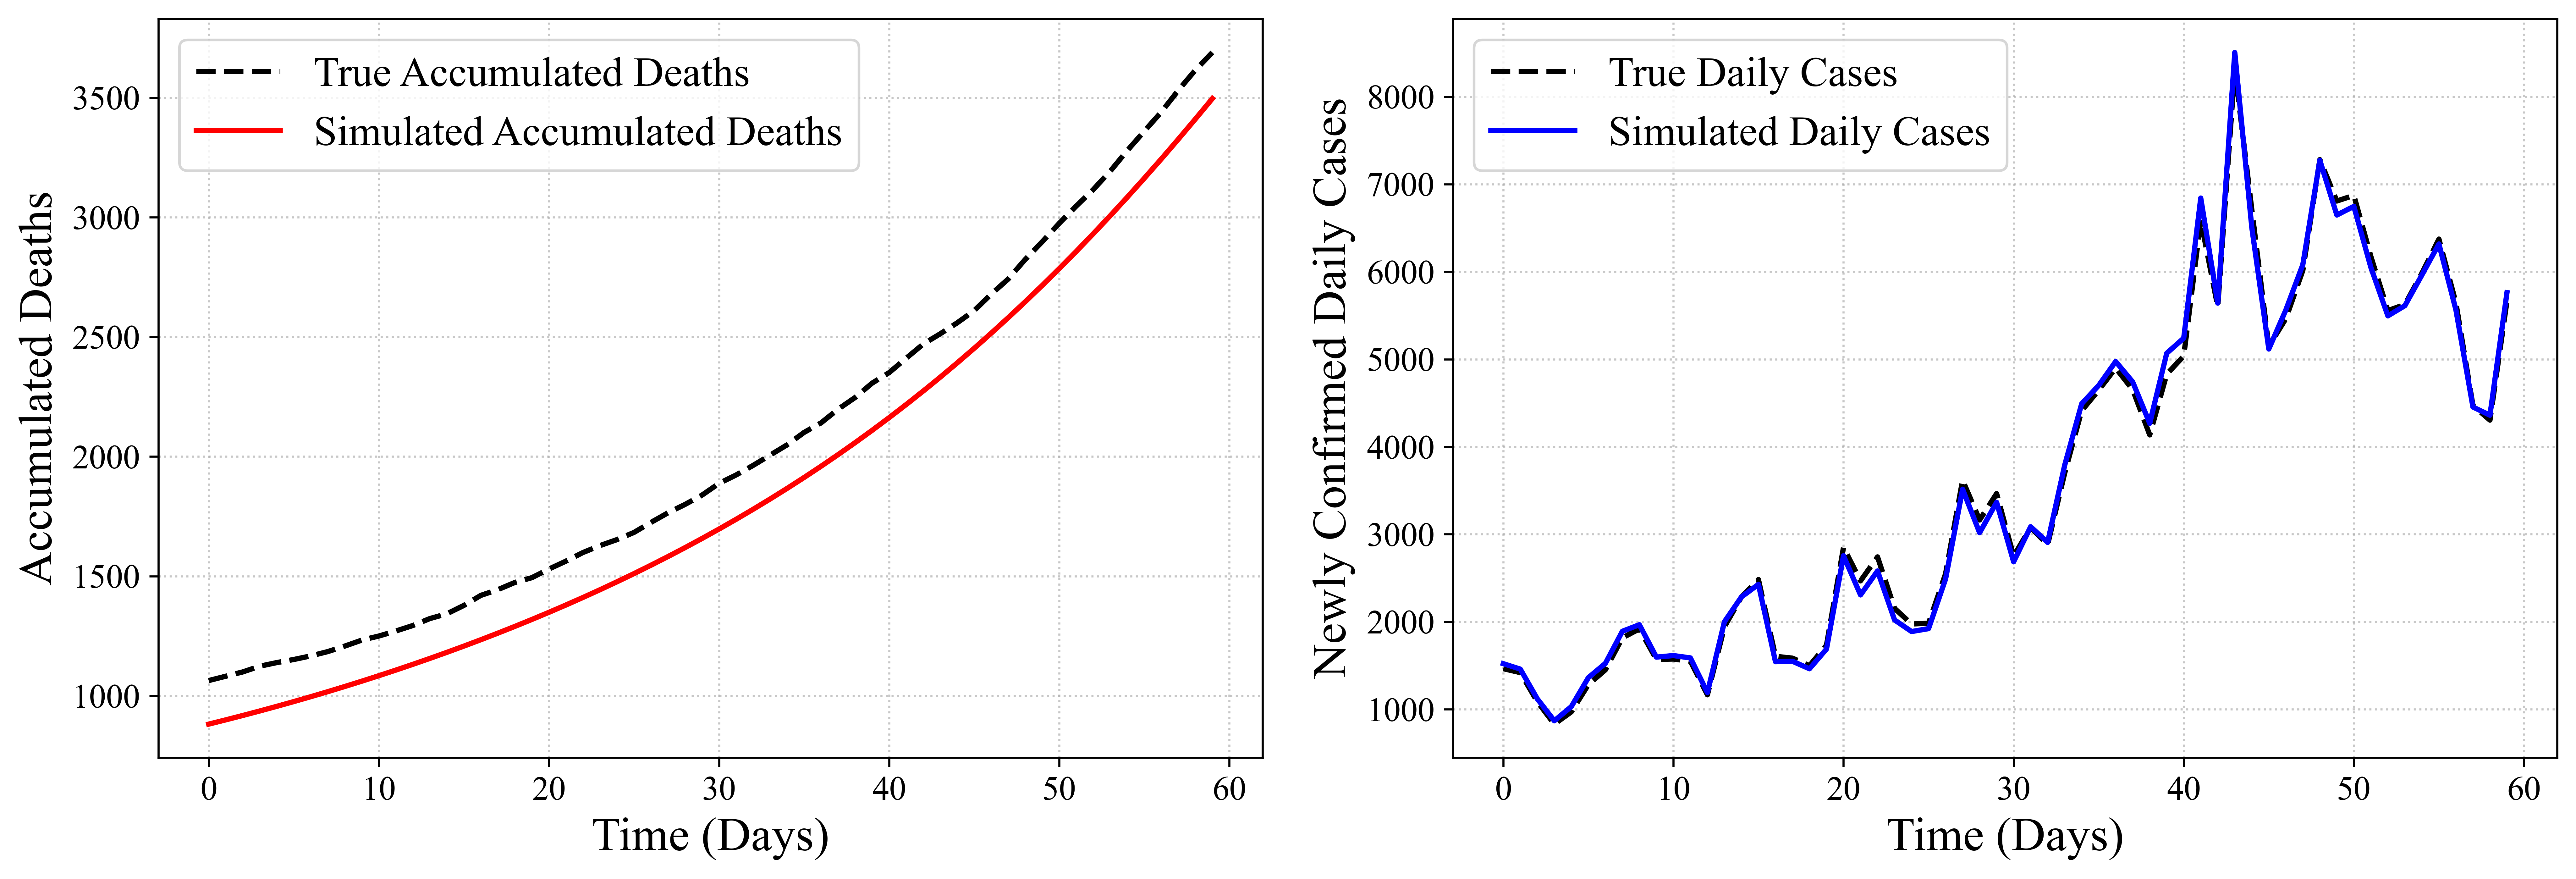

[np.float64(0.1009334751459611), np.float64(0.026126532456809314)]


In [104]:
import matplotlib.pyplot as plt
import numpy as np
import torch
start=90
end = 150
T = end - start + 2
def plot_calibration_comparison(true_death_acc, sim_death_acc, true_case, sim_case):
    """
    Plots the comparison between true data and simulated data for both
    accumulated deaths and newly confirmed daily cases.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    plt.rcParams.update({
        'font.family': 'Times New Roman',
        'font.size': 18,
        'axes.labelsize': 18,
        'xtick.labelsize': 13,
        'ytick.labelsize': 13,
        'figure.dpi': 600,
        'savefig.dpi': 600,
        'mathtext.fontset': 'stix'})
    
    # --- Plot 1: Accumulated Deaths ---
    axes[0].plot(true_death_acc, label='True Accumulated Deaths', color='black', linestyle='--', linewidth=2)
    axes[0].plot(sim_death_acc, label='Simulated Accumulated Deaths', color='red', linewidth=2)
    axes[0].set_xlabel('Time (Days)', fontsize=18)
    axes[0].set_ylabel('Accumulated Deaths', fontsize=18)
    axes[0].legend(fontsize=16)
    axes[0].grid(True, linestyle=':', alpha=0.7)

    # --- Plot 2: Newly Confirmed Daily Cases ---
    axes[1].plot(true_case, label='True Daily Cases', color='black', linestyle='--', linewidth=2)
    axes[1].plot(sim_case, label='Simulated Daily Cases', color='blue', linewidth=2)
    axes[1].set_xlabel('Time (Days)', fontsize=18)
    axes[1].set_ylabel('Newly Confirmed Daily Cases', fontsize=18)
    axes[1].legend(fontsize=16)
    axes[1].grid(True, linestyle=':', alpha=0.7)

    plt.tight_layout()
    plt.show()
    err_1 = np.abs(true_death_acc-sim_death_acc)/true_death_acc
    err_2 = np.abs(true_case-sim_case)/true_case
    print([np.mean(err_1),np.mean(err_2)])


def simulate_and_plot(env, calibrated_params, Init_state, actions, death_acc, case_data, T):
    """
    Runs one final simulation using the calibrated parameters and passes the 
    results to the plotting function.
    """
    beta1 = calibrated_params["beta1"]
    beta2 = calibrated_params["beta2"]
    pei   = calibrated_params["pei"]
    per   = calibrated_params["per"]
    
    sim_death_acc = [Init_state[0, 4].item() * env.N] 
    sim_case = []
    
    state = Init_state[:, :6].clone()
    state = state / state.sum() * env.N
    
    with torch.no_grad():
        for t in range(T-2):
            env.parameter_random = {
                "beta1": beta1[t].view(1),
                "beta2": beta2[t].view(1),
                "pei":   pei[t].view(1),
                "per":   per[t].view(1)
            }
            
            env.states = torch.cat([state / env.N, env.states[:, -2:]], dim=-1)
            next_state, _ = env.transition(actions[t:t+1])
            
            et = state[0, 1]
            w = actions[t, 4]
            pred_case = et * w * (1 - per[t] - pei[t])
            sim_case.append(pred_case.item())
            
            sim_death_acc.append(next_state[0, 4].item())
            
            state = next_state
            
    plot_calibration_comparison(
        true_death_acc=death_acc[start:end],
        sim_death_acc=sim_death_acc[start:end],
        true_case=case_data[start:end],
        sim_case=sim_case[start:end]
    )

# --- How to run it after your calibration finishes: ---
simulate_and_plot(env, results, Init_state, actions, death_acc, case_data, T=len(case_data))

✅ Success! Calibrated parameters saved to: 'calibrated_parameters.pt'


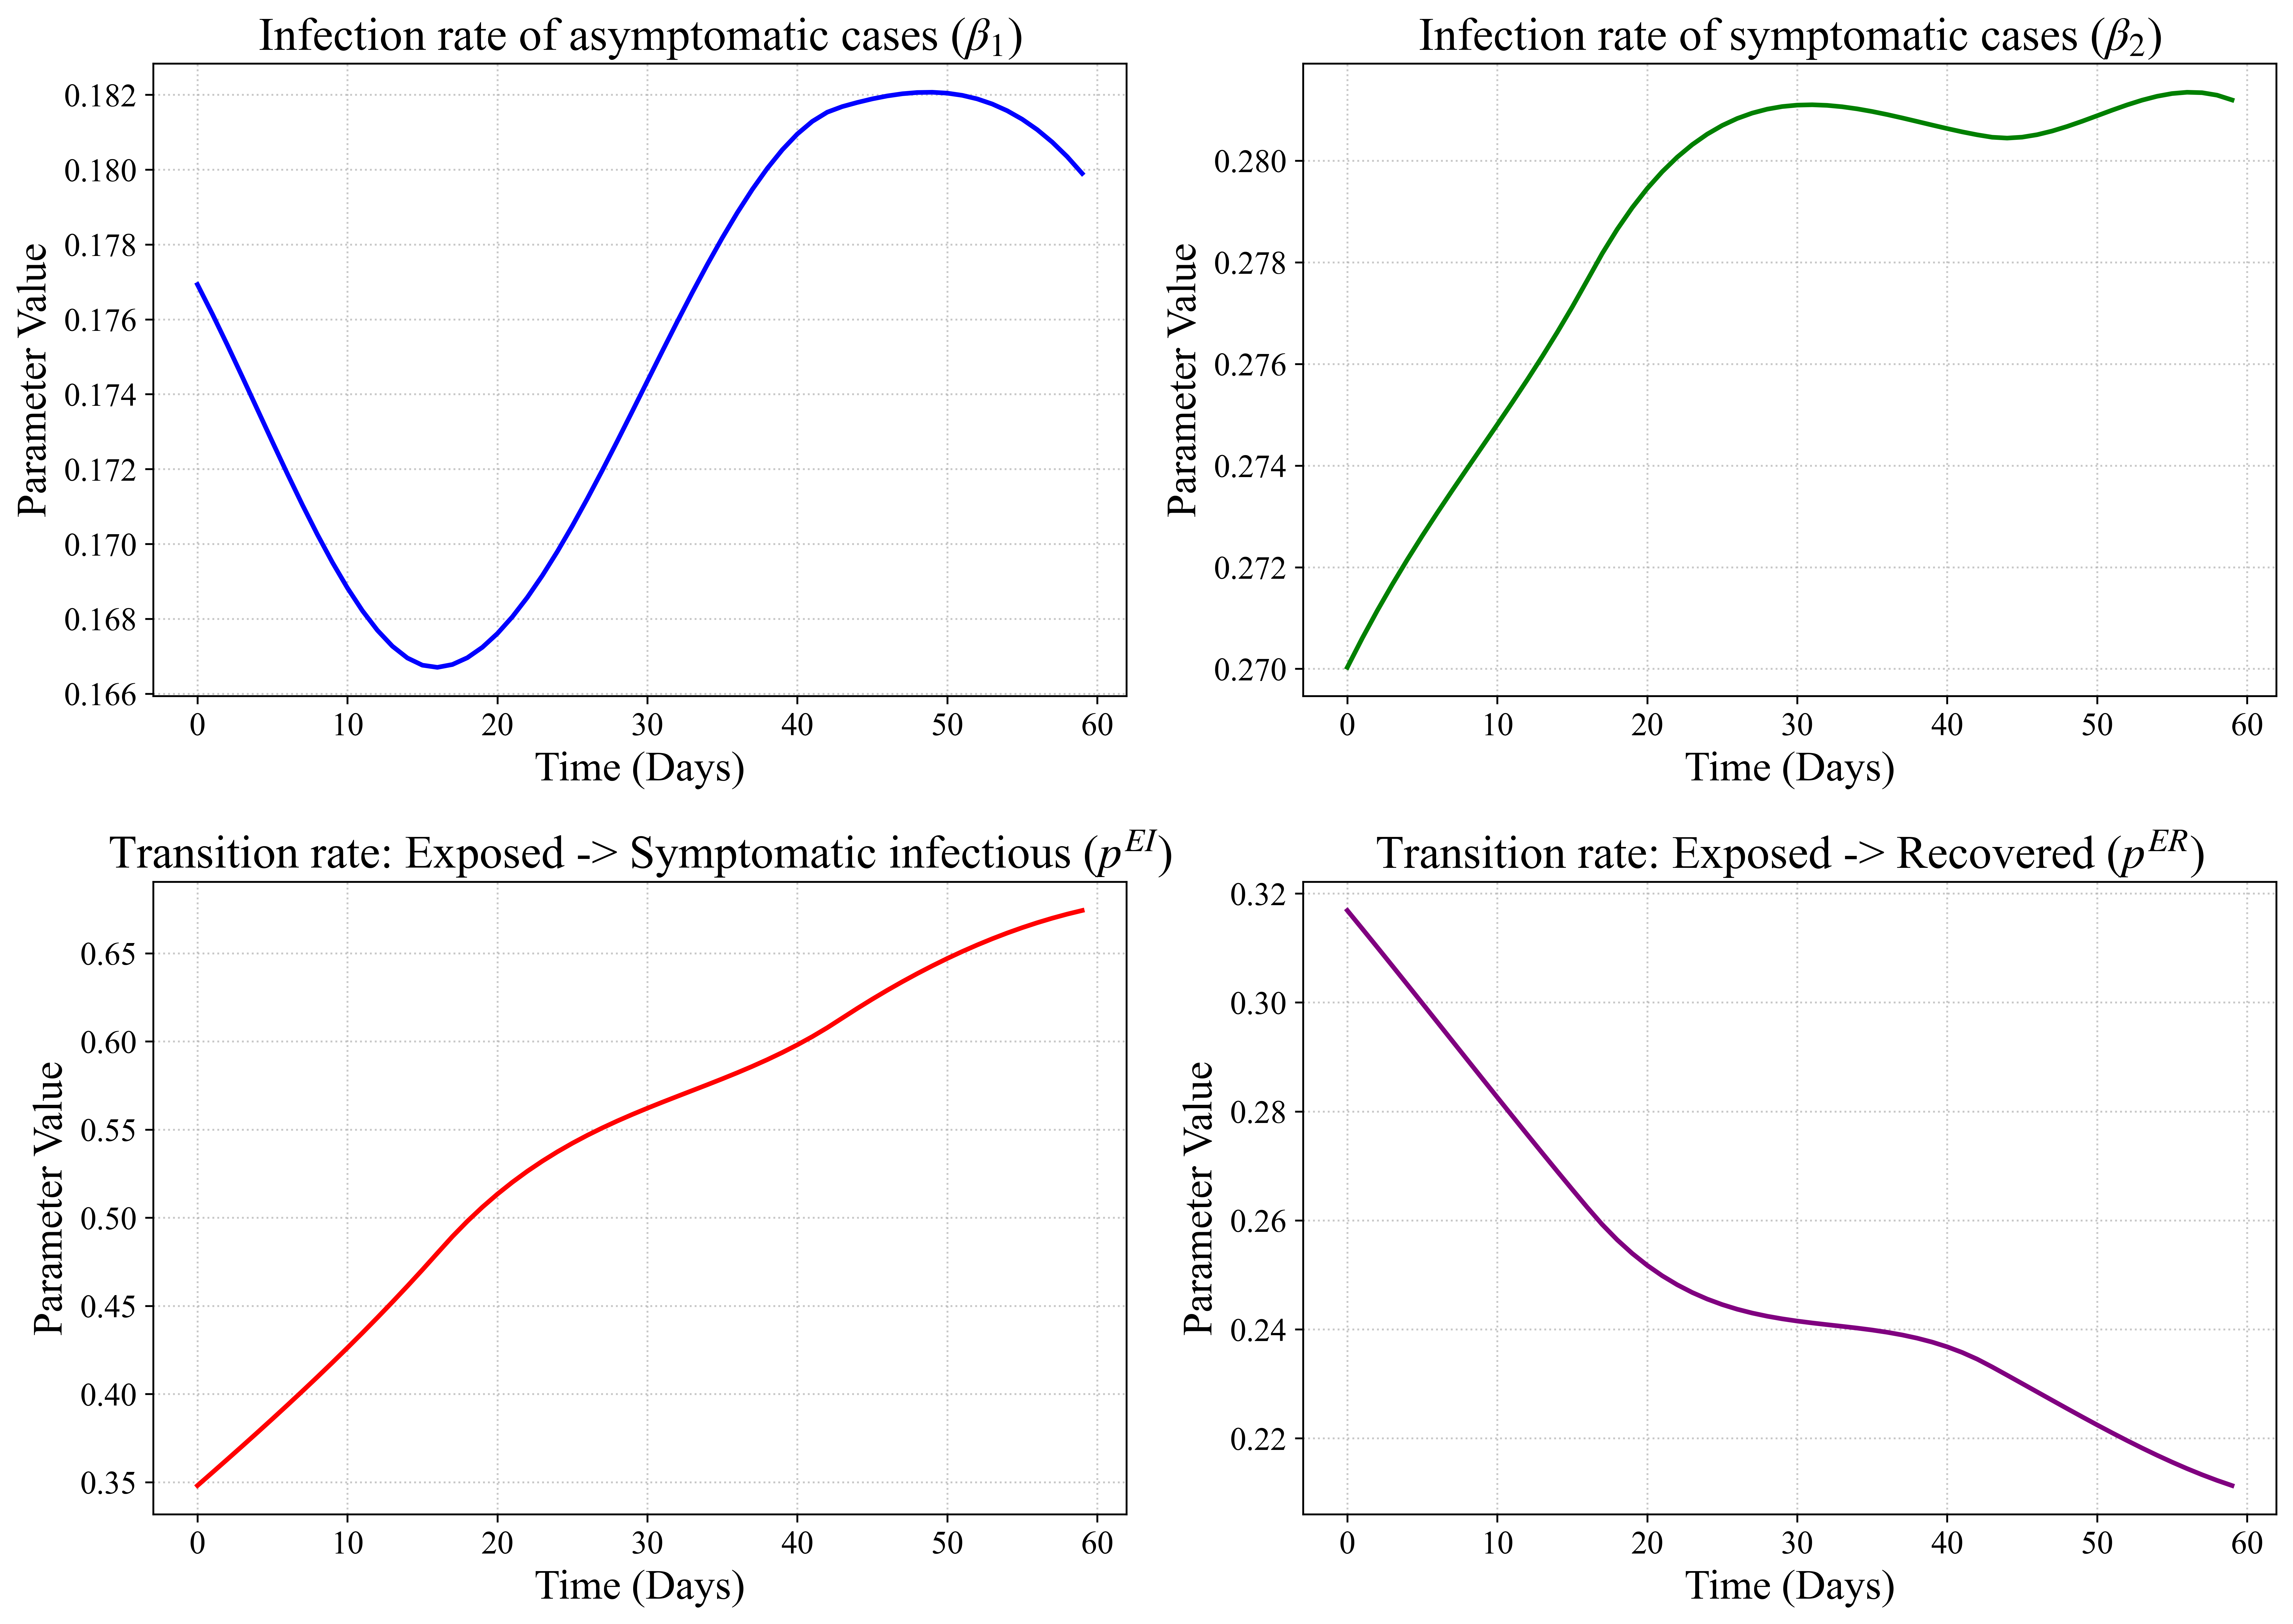

In [97]:
import matplotlib.pyplot as plt
import torch

def save_and_plot_parameters(results, save_filename="calibrated_parameters.pt"):
    """
    Saves the calibrated parameters dictionary to a PyTorch file, 
    and plots the 4 parameter trajectories in a 2x2 grid.
    """
    plt.rcParams.update({
        'font.family': 'Times New Roman',
        'xtick.labelsize': 14,
        'ytick.labelsize': 14,
        'figure.dpi': 600,
        'savefig.dpi': 600,
        'mathtext.fontset': 'stix'})
    # ==========================================
    # 1. SAVE THE RESULTS TO A PYTORCH FILE
    # ==========================================
    # torch.save serializes the dictionary of tensors perfectly.
    torch.save(results, save_filename)
    print(f"✅ Success! Calibrated parameters saved to: '{save_filename}'")
    
    # ==========================================
    # 2. EXTRACT DATA FOR PLOTTING
    # ==========================================
    # Move tensors to CPU and convert to numpy arrays for Matplotlib
    beta1 = results["beta1"][start:end].cpu().numpy()
    beta2 = results["beta2"][start:end].cpu().numpy()
    pei   = results["pei"][start:end].cpu().numpy()
    per   = results["per"][start:end].cpu().numpy()
    
    # ==========================================
    # 3. PLOT THE 4 SUBFIGURES
    # ==========================================
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Subfigure 1: beta1
    axes[0, 0].plot(beta1, color='blue', linewidth=2)
    axes[0, 0].set_title('Infection rate of asymptomatic cases ('r'$\beta_1$'')', fontsize=20)
    axes[0, 0].set_xlabel('Time (Days)', fontsize=18)
    axes[0, 0].set_ylabel('Parameter Value', fontsize=18)
    axes[0, 0].grid(True, linestyle=':', alpha=0.7)
    
    # Subfigure 2: beta2
    axes[0, 1].plot(beta2, color='green', linewidth=2)
    axes[0, 1].set_title('Infection rate of symptomatic cases ('r'$\beta_2$'')', fontsize=20)
    axes[0, 1].set_xlabel('Time (Days)', fontsize=18)
    axes[0, 1].set_ylabel('Parameter Value', fontsize=18)
    axes[0, 1].grid(True, linestyle=':', alpha=0.7)
    
    # Subfigure 3: pei
    axes[1, 0].plot(pei, color='red', linewidth=2)
    axes[1, 0].set_title('Transition rate: Exposed -> Symptomatic infectious ('r'$p^{EI}$'')', fontsize=20)
    axes[1, 0].set_xlabel('Time (Days)', fontsize=18)
    axes[1, 0].set_ylabel('Parameter Value', fontsize=18)
    axes[1, 0].grid(True, linestyle=':', alpha=0.7)
    
    # Subfigure 4: per
    axes[1, 1].plot(per, color='purple', linewidth=2)
    axes[1, 1].set_title('Transition rate: Exposed -> Recovered ('r'$p^{ER}$'')', fontsize=20)
    axes[1, 1].set_xlabel('Time (Days)', fontsize=18)
    axes[1, 1].set_ylabel('Parameter Value', fontsize=18)
    axes[1, 1].grid(True, linestyle=':', alpha=0.7)
    
    # Adjust layout so titles and labels don't overlap
    plt.tight_layout()
    plt.show()

# --- HOW TO RUN IT ---
# Assuming your calibration output is saved in the variable `results`
save_and_plot_parameters(results, save_filename="calibrated_parameters.pt")

In [93]:
result1={}
result1["beta1"] = results["beta1"][start:end]
result1["beta2"] = results["beta2"][start:end]
result1["pei"]   = results["pei"][start:end]
result1["per"]   = results["per"][start:end]
torch.save(result1, "calibrated_parameters.pt")

In [109]:
import matplotlib.pyplot as plt
import torch

def save_and_plot_parameters(results, save_filename="calibrated_parameters.pt"):
    """
    Saves the calibrated parameters dictionary to a PyTorch file, 
    and plots the 4 parameter trajectories in a 1x4 grid.
    """
    plt.rcParams.update({
        'font.family': 'Times New Roman',
        'xtick.labelsize': 14,
        'ytick.labelsize': 14,
        'figure.dpi': 600,
        'savefig.dpi': 600,
        'mathtext.fontset': 'stix'})
    # ==========================================
    # 1. SAVE THE RESULTS TO A PYTORCH FILE
    # ==========================================
    # torch.save serializes the dictionary of tensors perfectly.
    torch.save(results, save_filename)
    print(f"✅ Success! Calibrated parameters saved to: '{save_filename}'")
    
    # ==========================================
    # 2. EXTRACT DATA FOR PLOTTING
    # ==========================================
    # Move tensors to CPU and convert to numpy arrays for Matplotlib
    # (假设 start 和 end 已经在全局变量中定义，或你可以将其加入函数参数)
    beta1 = results["beta1"][start:end].cpu().numpy()
    beta2 = results["beta2"][start:end].cpu().numpy()
    pei   = results["pei"][start:end].cpu().numpy()
    per   = results["per"][start:end].cpu().numpy()
    
    # ==========================================
    # 3. PLOT THE 4 SUBFIGURES
    # ==========================================
    # 改为 1x4 结构。调整 figsize 以保证每个子图的长宽比与之前保持一致
    fig, axes = plt.subplots(1, 4, figsize=(28, 6))
    
    # Subfigure 1: beta1
    axes[0].plot(beta1, color='blue', linewidth=2)
    axes[0].set_title('Infection rate of asymptomatic cases ('r'$\beta_1$'')', fontsize=20)
    axes[0].set_xlabel('Time (Days)', fontsize=18)
    axes[0].set_ylabel('Parameter Value', fontsize=18)
    axes[0].grid(True, linestyle=':', alpha=0.7)
    
    # Subfigure 2: beta2
    axes[1].plot(beta2, color='green', linewidth=2)
    axes[1].set_title('Infection rate of symptomatic cases ('r'$\beta_2$'')', fontsize=20)
    axes[1].set_xlabel('Time (Days)', fontsize=18)
    axes[1].set_ylabel('Parameter Value', fontsize=18)
    axes[1].grid(True, linestyle=':', alpha=0.7)
    
    # Subfigure 3: pei
    axes[2].plot(pei, color='red', linewidth=2)
    axes[2].set_title('Transition rate: Exposed -> Symptomatic infectious ('r'$p^{EI}$'')', fontsize=20)
    axes[2].set_xlabel('Time (Days)', fontsize=18)
    axes[2].set_ylabel('Parameter Value', fontsize=18)
    axes[2].grid(True, linestyle=':', alpha=0.7)
    
    # Subfigure 4: per
    axes[3].plot(per, color='purple', linewidth=2)
    axes[3].set_title('Transition rate: Exposed -> Recovered ('r'$p^{ER}$'')', fontsize=20)
    axes[3].set_xlabel('Time (Days)', fontsize=18)
    axes[3].set_ylabel('Parameter Value', fontsize=18)
    axes[3].grid(True, linestyle=':', alpha=0.7)
    
    # Adjust layout so titles and labels don't overlap
    plt.tight_layout()
    plt.show()

# --- HOW TO RUN IT ---
# Assuming your calibration output is saved in the variable `results`
save_and_plot_parameters(results, save_filename="calibrated_parameters.pt")

✅ Success! Calibrated parameters saved to: 'calibrated_parameters.pt'
